# **A/B Testing:** Does the New Landing Page Improve Conversion Rate?

**Objective:** Evaluate whether a new landing page improves conversion rates for an e-commerce website.

**Dataset:** ~300,000 users randomly assigned to old and new landing page variants.

**Approach:** Clean and validate the data, analyze conversion rates, and apply statistical testing (Z-test) to determine whether the new page leads to a meaningful improvement. Additional analysis explores the impact of time spent on conversion.

**Tools**: Python, Pandas, Matplotlib, Seaborn, SciPy, Statsmodels

**Key Insight:** The new landing page does not significantly improve conversion rates and shows only a negligible effect size, indicating no meaningful business impact.

# Importing Libraries and Data Loading

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.stats.proportion import proportions_ztest  # for Z-test
from statsmodels.stats.proportion import proportion_confint

In [ ]:
df = pd.read_csv('/content/ab_test.csv')
df.head()

,id,time,con_treat,page,converted
0,851104,11:48.6,control,old_page,0
1,804228,01:45.2,control,old_page,0
2,661590,55:06.2,treatment,new_page,0
3,853541,28:03.1,treatment,new_page,0
4,864975,52:26.2,control,old_page,1


**Data Cleaning**

In [ ]:
# Rename 'con_treat' to 'group'

df.rename(columns={'con_treat': 'group'}, inplace=True)
print(df.columns)

Index(['id', 'time', 'group', 'page', 'converted'], dtype='object')


In [ ]:
# To understand what are the unique value in 'group', 'converted' and 'page'

# Unique value in "group"
print(df['group'].unique())

# Unique value in 'page'
print(df['page'].unique())

# Unique value in 'converted'
print(df['converted'].unique())

['control' 'treatment']
['old_page' 'new_page']
[0 1]


In [ ]:
# Check for missing values

missing_values = df.isnull().sum()

print('Missing values per column:')
print(missing_values)

Missing values per column:
id           0
time         0
group        0
page         0
converted    0
dtype: int64


There is no missing value in the dataset

In [ ]:
# Duplicates

# Check for exact duplicate rows across all columns
duplicate_rows = df.duplicated()

# Number of exact duplicate rows
print('Number of exact duplicate rows:', duplicate_rows.sum())

# Optionally, view the duplicate rows
print('Exact duplicate rows:')
print(df[duplicate_rows])

Number of exact duplicate rows: 0
Exact duplicate rows:
Empty DataFrame
Columns: [id, time, group, page, converted]
Index: []


There is no exact duplicate rows in the dataset

Mismatch:

In this study, the only valid combinations are control =old_page and treatment = new_page. Any other combination is considered a mismatch and should be excluded from the analysis.



In [ ]:
# Find and remove mismatched rows between 'group' and 'page'

mismatch_mask = (
    ((df['group'] == 'control') & (df['page'] != 'old_page')) |
    ((df['group'] == 'treatment') & (df['page'] != 'new_page'))
)

# Count how many mismatched rows
num_mismatches = mismatch_mask.sum()
print(f'Number of mismatched rows: {num_mismatches}')
print('Dimension before removal of mismatched:', df.shape)

# Keep only rows that are consistent
df = df[~mismatch_mask]
print('Dimension after removal of mismatched:', df.shape)

Number of mismatched rows: 3893
Dimension before removal of mismatched: (294478, 5)
Dimension after removal of mismatched: (290585, 5)


A total of 3,893 mismatched rows were identified and removed from further analysis.

In [ ]:
# Identify users who saw both pages

users_both_pages = df.groupby('id')['page'].nunique()
users_both_pages = users_both_pages[users_both_pages == 2].index

len(users_both_pages)



0

Each user viewed either the new page or the old page.

**EDA**

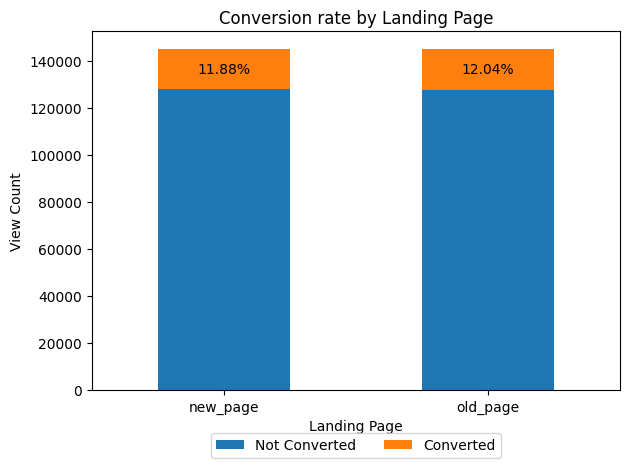

In [ ]:
# Check for data distribution

# Create contingency table
ct = pd.crosstab(df['page'], df['converted'])

# Plot stacked bar chart
ax = ct.plot(kind='bar', stacked=True)

# Labels and title
plt.title('Conversion rate by Landing Page')
plt.xlabel('Landing Page')
plt.ylabel('View Count')
plt.xticks(rotation=0)

# Move legend to bottom
plt.legend(['Not Converted', 'Converted'], loc='upper center',
           bbox_to_anchor=(0.5, -0.1), ncol=2)

# Calculate conversion rates
conversion_rates = ct[1] / (ct[0] + ct[1])

# Add conversion rate labels on the orange bars
for i, (not_conv, conv) in enumerate(zip(ct[0], ct[1])):
    total = not_conv + conv
    rate = conv / total

    # Position text in the middle of the orange (converted) section
    ax.text(i, not_conv + conv/2,
            f"{rate:.2%}",
            ha='center', va='center', fontsize=10, color='black')

plt.tight_layout()
plt.show()

Views are evenly split between the new and old pages, and their conversion rates are similar (new page = 11.88%; old page = 12.04%) . Further analysis will determine if the difference is statistically significant.

**Feature Engineering**

In [ ]:
# Function to convert 'xx:xx.x' to total minutes
def time_to_minutes(t):
    mins, sec = t.split(":")
    total_minutes = int(mins) + float(sec) / 60
    return round(total_minutes, 1)

# Apply function
df['time_minutes'] = df['time'].apply(time_to_minutes)

# Check result
df[['time', 'time_minutes']].head()

,time,time_minutes
0,11:48.6,11.8
1,01:45.2,1.8
2,55:06.2,55.1
3,28:03.1,28.1
4,52:26.2,52.4


converted          0          1
page                           
new_page   30.019221  30.070783
old_page   30.099507  29.954017


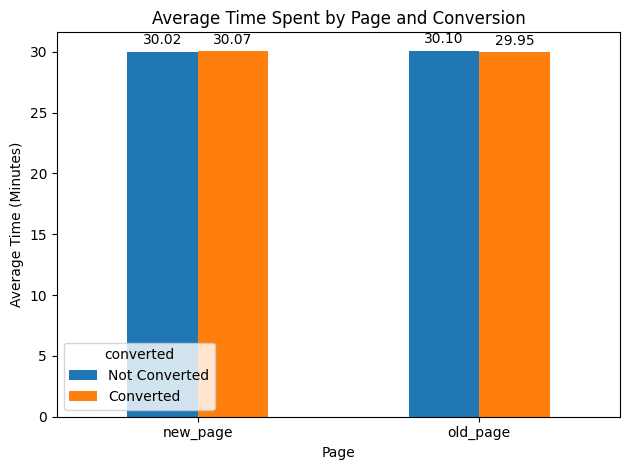

In [ ]:
# Average time spent on viewing the page
avg_time = df.groupby(['page', 'converted'])['time_minutes'].mean().unstack()
print(avg_time)

# Plot grouped bar chart
ax = avg_time.plot(kind='bar')

# Labels and title
plt.title('Average Time Spent by Page and Conversion')
plt.xlabel('Page')
plt.ylabel('Average Time (Minutes)')
plt.xticks(rotation=0)

# Legend labels (0 = Not Converted, 1 = Converted)
plt.legend(['Not Converted', 'Converted'], title='converted')

# Add value labels on bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3)

plt.tight_layout()
plt.show()

Users spend roughly the same amount of time on both the old and new landing pages, regardless of whether they convert. Preliminary analysis suggests that session duration does not meaningfully differ between groups.

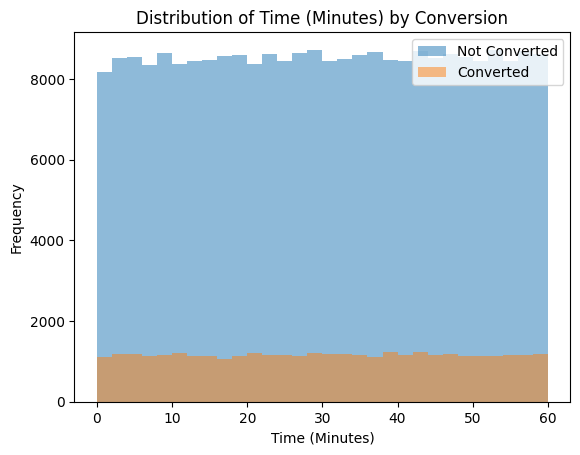

In [ ]:
# Time distribution for converted vs. non-converted users.

# Separate data
converted = df[df['converted'] == 1]['time_minutes']
not_converted = df[df['converted'] == 0]['time_minutes']

# Plot
plt.hist(not_converted, bins=30, alpha=0.5, label='Not Converted')
plt.hist(converted, bins=30, alpha=0.5, label='Converted')

plt.title('Distribution of Time (Minutes) by Conversion')
plt.xlabel('Time (Minutes)')
plt.ylabel('Frequency')
plt.legend()

plt.show()



The distribution of time spent appears similar across groups, with no obvious differences between converted and non-converted users.


##**Analysis**

**A/B testing ** :Does New landing page imporve conversion rate?

*Note: Either a Z-test or a Chi-square test can be used, as both are appropriate for this type of analysis. *


Ho = The new Landing page does not increase conversion rate.

H1 = The new landing page leads to a higher conversion rate than the old page.


Note: A two-proportion Z-test is used for this analysis. While a Chi-square test is also applicable for this type of data, both methods are equivalent for a 2×2 setup and would yield the same conclusion.

### **A/B testing using Z-test**


In [ ]:
# Z-test f

# Count conversions for each page
conversion_counts = df.groupby('page')['converted'].sum()

# Count total users for each page
n_obs = df.groupby('page')['converted'].count()

print('Conversions:\n', conversion_counts)
print('\nTotal observations:\n', n_obs)

Conversions:
 page
new_page    17264
old_page    17489
Name: converted, dtype: int64

Total observations:
 page
new_page    145311
old_page    145274
Name: converted, dtype: int64


In [ ]:
# Successes (number of conversions)
success = [conversion_counts['new_page'], conversion_counts['old_page']]

# Total observations
n = [n_obs['new_page'], n_obs['old_page']]

In [ ]:
# run Z-test

z_stat, p_value = proportions_ztest(count=success, nobs=n)

print(f'Z-statistic: {z_stat:.4f}')
print(f'P-value: {p_value:.4f}')

Z-statistic: -1.3116
P-value: 0.1897


In [ ]:
alpha = 0.05

if p_value < alpha:
    print('Reject H0: Significant difference in conversion rates')
else:
    print('Fail to reject H0: No significant difference in conversion rates')

Fail to reject H0: No significant difference in conversion rates


A two-proportion Z-test was conducted to compare conversion rates between the new and old landing pages. The results (Z = -1.31, p = 0.1897) indicate that the difference is not statistically significant at the 5% level. Therefore, we fail to reject the null hypothesis and conclude that the new landing page does not significantly improve conversion rates.

In [ ]:
# Confidence Intervals

# Get counts
conversions = df.groupby('page')['converted'].sum()
n_obs = df.groupby('page')['converted'].count()

# Compute conversion rates
conversion_rates = conversions / n_obs

# Confidence intervals (95%)
ci_lower, ci_upper = proportion_confint(conversions, n_obs, alpha=0.05, method='normal')

# Create summary table
ci_df = pd.DataFrame({
    'conversion_rate': conversion_rates,
    'ci_lower': ci_lower,
    'ci_upper': ci_upper
})

print(ci_df)

          conversion_rate  ci_lower  ci_upper
page                                         
new_page         0.118807  0.117144  0.120471
old_page         0.120386  0.118713  0.122060


Conversion rates for the new and old pages are nearly identical, with overlapping confidence intervals and no statistically significant difference. This suggests the new design does not meaningfully impact user conversion.

In [ ]:
# Effect Size

# Conversion rate difference
diff = conversion_rates['new_page'] - conversion_rates['old_page']

print(f"Conversion rate (new page): {conversion_rates['new_page']:.4f}")
print(f"Conversion rate (old page): {conversion_rates['old_page']:.4f}")
print(f"Absolute difference: {diff:.4%}")

Conversion rate (new page): 0.1188
Conversion rate (old page): 0.1204
Absolute difference: -0.1579%


The new landing page has a conversion rate of 11.88%, compared to 12.04% for the old page, resulting in an absolute difference of -0.16 percentage points. This indicates that the new page performs slightly worse; however, the magnitude of this difference is extremely small. In practical terms, this corresponds to roughly 1–2 fewer conversions per 1,000 users, suggesting a negligible business impact.

Overall Conclusion: The new landing page does not significantly change conversion rates—it neither improves nor harms performance.

### **Bonus Analysis:**

Does spending more time on the landing page improve conversion rates?

In [ ]:


X = sm.add_constant(df['time_minutes'])
y = df['converted']

model = sm.Logit(y, X).fit()
print(model.summary())

Optimization terminated successfully.
         Current function value: 0.366120
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:              converted   No. Observations:               290585
Model:                          Logit   Df Residuals:                   290583
Method:                           MLE   Df Model:                            1
Date:                Mon, 06 Apr 2026   Pseudo R-squ.:               1.075e-06
Time:                        21:34:04   Log-Likelihood:            -1.0639e+05
converged:                       True   LL-Null:                   -1.0639e+05
Covariance Type:            nonrobust   LLR p-value:                    0.6325
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const           -1.9915      0.011   -173.950      0.000      -2.014      -1.969
time_minutes    -0.0002

Conclusion:
Logistic regression results show that time spent on the page is not a statistically significant predictor of conversion (p > 0.05), confirming that session duration does not meaningfully influence conversion likelihood.

## **Executive Summary:**
The A/B test results indicate that the new landing page does not significantly improve conversion rates compared to the old page. The observed difference is minimal (~0.16 percentage points) and not statistically significant. Additionally, time spent on the page does not meaningfully influence conversion behavior.

From a business perspective, implementing the new page would not lead to measurable gains in conversion and should not be prioritized without further optimization.



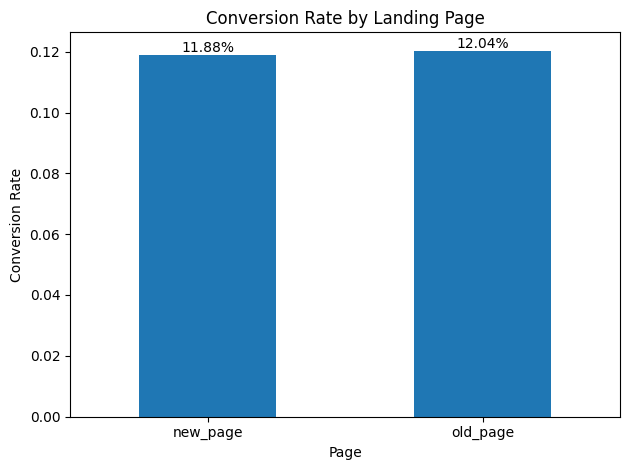

In [ ]:
# Conversion rate by page
conversion_rates = df.groupby('page')['converted'].mean()

# Plot
conversion_rates.plot(kind='bar')

plt.title('Conversion Rate by Landing Page')
plt.xlabel('Page')
plt.ylabel('Conversion Rate')
plt.xticks(rotation=0)

# Add labels
for i, v in enumerate(conversion_rates):
    plt.text(i, v + 0.001, f"{v:.2%}", ha='center')

plt.tight_layout()
plt.show()

## **Recommended Next Steps:**

1.**Keep Monitoring:** Track conversion trends over time to detect any changes.

2.**Make small improvements**: Keep testing small changes (e.g. button, content, short messages) to find what works best.

3.**Look at different users:** Check if new vs. returning
users, or mobile vs. desktop, different age or gender group, respond differently.

